<a href="https://colab.research.google.com/github/Marteldelfer/PISI3/blob/main/SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('tmdb_new.csv')
# Display information about the DataFrame

# 2. Pré-processamento (ajuste conforme seus dados)
df = df.dropna()  # Remove valores ausentes

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8435 entries, 0 to 11984
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       8435 non-null   int64  
 1   title                    8435 non-null   object 
 2   vote_average             8435 non-null   float64
 3   vote_count               8435 non-null   float64
 4   release_date             8435 non-null   object 
 5   revenue                  8435 non-null   float64
 6   runtime                  8435 non-null   float64
 7   budget                   8435 non-null   float64
 8   original_language        8435 non-null   object 
 9   popularity               8435 non-null   float64
 10  genres                   8435 non-null   object 
 11  production_companies     8435 non-null   object 
 12  production_countries     8435 non-null   object 
 13  cast                     8435 non-null   object 
 14  director                 843

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Leitura do CSV
df = pd.read_csv('tmdb_new.csv')

# 2. Seleção das colunas
target_column = 'runtime'
feature_columns = ['budget', 'popularity', 'vote_average', 'vote_count']

# Verificação das colunas
if target_column not in df.columns:
    raise ValueError(f"Erro: A coluna alvo '{target_column}' não foi encontrada.")
missing_cols = [col for col in feature_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"Erro: As colunas {missing_cols} não foram encontradas no DataFrame.")

# 3. Limpar os dados (remover linhas com valores faltantes nas colunas selecionadas)
df = df.dropna(subset=feature_columns + [target_column])

# 4. Seleção de X e y
X = df[feature_columns]
y = df[target_column]

# 5. Categorização da variável target 'runtime'
def categorize_runtime(runtime):
    if runtime < 90:
        return 'curto'
    elif runtime < 120:
        return 'medio'
    else:
        return 'longo'

y_classified = y.apply(categorize_runtime)

# 6. Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_classified, test_size=0.2, random_state=42)

# 7. Criação e treinamento do modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 8. Previsões
y_pred = model.predict(X_test)

# 9. Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\nAcurácia do modelo:", round(accuracy, 4))
print("\nRelatório de Classificação:\n", report)



Acurácia do modelo: 0.6027

Relatório de Classificação:
               precision    recall  f1-score   support

       curto       0.45      0.21      0.29       384
       longo       0.51      0.38      0.44       608
       medio       0.64      0.80      0.71      1412

    accuracy                           0.60      2404
   macro avg       0.53      0.47      0.48      2404
weighted avg       0.58      0.60      0.58      2404



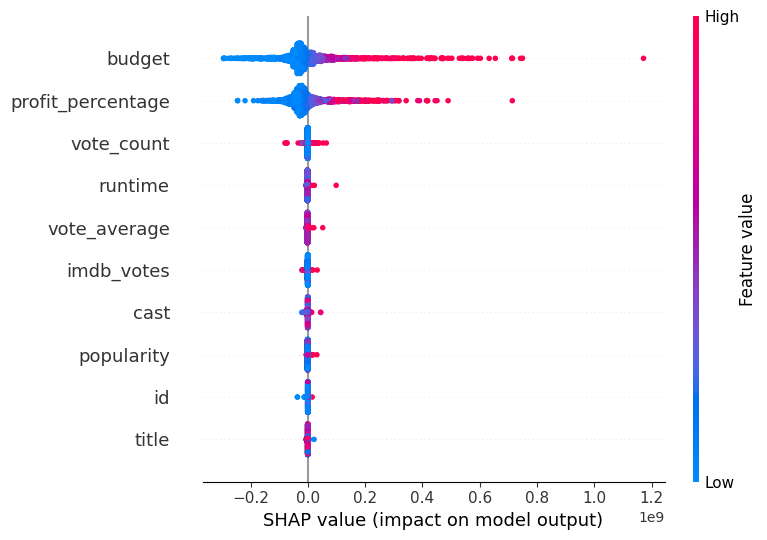

In [7]:
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error


# Supondo que 'revenue' seja a variável alvo
target = 'revenue'

# Remover colunas que não são numéricas ou precisam ser tratadas
X = df.drop(columns=[target])
y = df[target]

# Codificar colunas categóricas (se houver)
for col in X.select_dtypes(include=['object', 'category']):
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 3. Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinar modelo
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

# 5. Calcular valores SHAP
# Create a background dataset for the explainer
background_data = shap.maskers.Independent(X_train)

explainer = shap.Explainer(model, background_data, feature_perturbation='interventional')
shap_values = explainer(X_test)

# 6. Visualizar os valores SHAP
shap.summary_plot(shap_values, X_test, max_display=10)

RMSE: 28246959.04


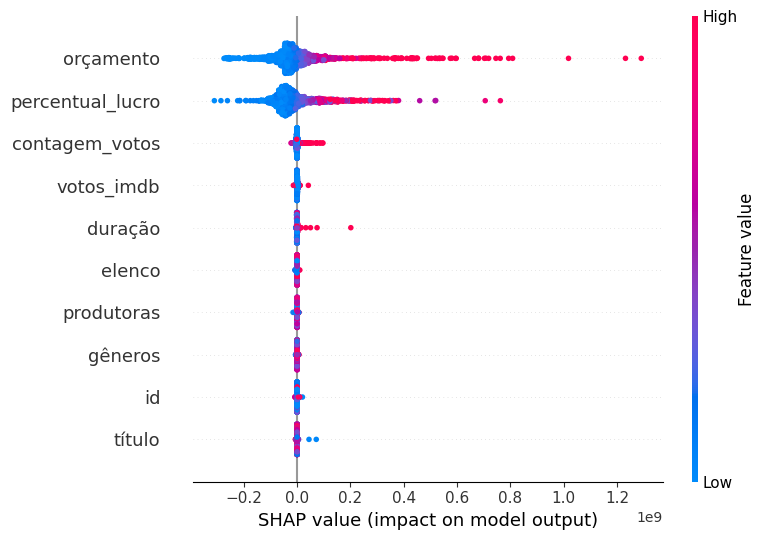

In [6]:
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregar os dados
df = pd.read_csv('tmdb_new.csv')

# 2. Definir variável alvo e features
target = 'revenue'
X = df.drop(columns=[target])
y = df[target]

# 3. Tratar valores ausentes
X = X.dropna()
y = y.loc[X.index]  # manter alinhado com X após remoção de NaNs

# 4. Codificar colunas categóricas
for col in X.select_dtypes(include=['object', 'category']):
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 5. Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Renomear colunas para português
column_translations = {
    'id': 'id', # Manter como está
    'title': 'título',
    'vote_average': 'média_votos',
    'vote_count': 'contagem_votos',
    'release_date': 'data_lançamento',
    'runtime': 'duração',
    'budget': 'orçamento',
    'original_language': 'idioma_original',
    'popularity': 'popularidade',
    'genres': 'gêneros',
    'production_companies': 'produtoras',
    'production_countries': 'países_produção',
    'cast': 'elenco',
    'director': 'diretor',
    'director_of_photography': 'diretor_fotografia',
    'writers': 'escritores',
    'producers': 'produtores',
    'music_composer': 'compositor_musica',
    'imdb_rating': 'avaliação_imdb',
    'imdb_votes': 'votos_imdb',
    'profit_percentage': 'percentual_lucro'
}

X_train = X_train.rename(columns=column_translations)
X_test = X_test.rename(columns=column_translations)


# 7. Treinar modelo
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 8. Avaliação rápida (opcional)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# 9. Calcular valores SHAP
background_data = shap.maskers.Independent(X_train)
explainer = shap.Explainer(model, background_data, feature_perturbation='interventional')
shap_values = explainer(X_test)

# 10. Plotar resumo dos valores SHAP
shap.summary_plot(shap_values, X_test, max_display=10)